## Face recognition

In [3]:
from tensorflow.python.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,ZeroPadding2D,Dropout,Softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.python.keras import Sequential
from sklearn.datasets import fetch_lfw_people
from sklearn.datasets import fetch_lfw_pairs
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import scikitplot as skplt
import numpy as np
import random

# Commented out IPython magic to ensure Python compatibility.
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow_datasets as tfds
import tensorflow as tf
tf.test.gpu_device_name()

''

## Fetch Data

In [4]:
data=fetch_lfw_people(resize=0.4,min_faces_per_person=40,funneled=False)

In [5]:
l=list(data.keys())
print(l)

['data', 'images', 'target', 'target_names', 'DESCR']


In [53]:
X=data["data"]
Y=data["target"]
images=data["images"]
target_name=data["target_names"]

In [54]:
np.unique(Y,return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18], dtype=int64),
 array([ 77,  42, 236, 121, 530, 109,  44,  71,  52,  55,  42,  53,  60,
         41,  41,  48,  52, 144,  49], dtype=int64))

In [55]:
np.unique(target_name,return_counts=True)

(array(['Ariel Sharon', 'Arnold Schwarzenegger', 'Colin Powell',
        'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder',
        'Gloria Macapagal Arroyo', 'Hugo Chavez', 'Jacques Chirac',
        'Jean Chretien', 'Jennifer Capriati', 'John Ashcroft',
        'Junichiro Koizumi', 'Laura Bush', 'Lleyton Hewitt',
        'Luiz Inacio Lula da Silva', 'Serena Williams', 'Tony Blair',
        'Vladimir Putin'], dtype='<U25'),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       dtype=int64))

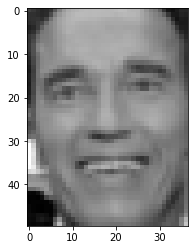

In [56]:
target=list(target_name).index("Arnold Schwarzenegger")
indexes=np.where(Y == target)
plt.imshow(images[indexes[0][0],:,:],cmap="gray")

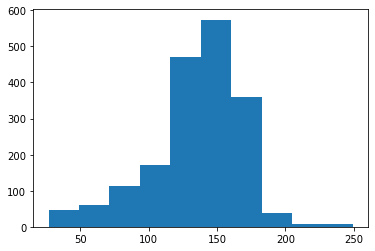

In [57]:
_=plt.hist(images[indexes[0][0],:,:].flatten())

In [40]:
_,W,H=images.shape
features = X.shape[1]
m = X.shape[0]
classes = target_name.shape[0]

print("Samples:",m)
print("Features:",features)
print("Classes:",classes)
print("Dimension per image:",(W,H))

Samples: 1867
Features: 1850
Classes: 19
Dimension per image: (50, 37)


## Prepare Training

In [41]:
### Shuffling the data ###

temp=list(zip(X,Y)) 
random.shuffle(temp) 
X,Y=zip(*temp)

X=np.array(X)
Y=np.array(Y)

In [42]:
####### Train and test splitting of data #######

training_data_X,testing_data_X,training_data_Y,testing_data_Y=train_test_split(X,Y,test_size=0.20,random_state=42)

## Create Model

In [44]:
from tensorflow.keras.utils import to_categorical
import time

####### CNN #######
model=Sequential()

model.add(Conv2D(64,kernel_size = 3,activation = 'relu',input_shape = (W,H,1)))
model.add(MaxPooling2D((2,2),strides = (2,2)))
model.add(Conv2D(128,kernel_size = 3,activation = 'relu'))
model.add(MaxPooling2D((2,2),strides = (2,2)))
model.add(Conv2D(256,kernel_size = 5,activation = 'relu'))
model.add(MaxPooling2D((2,2),strides = (2,2)))
model.add(Dropout(0.25))
#model.add(Conv2D(512,kernel_size = 3,activation = 'relu'))
#model.add(MaxPooling2D((2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(classes,activation = 'softmax'))



training_data_Y = to_categorical(training_data_Y)
testing_data_Y = to_categorical(testing_data_Y)
training_data_X = training_data_X.reshape(training_data_X.shape[0],W,H,1)
testing_data_X = testing_data_X.reshape(testing_data_X.shape[0],W,H,1)


# Measuring the time taken by the model to train
start_time = time.time()
model.compile(optimizer='Adamax',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(training_data_X,training_data_Y,validation_data = (testing_data_X, testing_data_Y),batch_size = 100,epochs = 50)
end_time = time.time()


print("###### Total Time Taken: ", round((end_time - start_time)/60), 'Minutes ######')

Epoch 1/50
15/15 [==============================] - 7s 388ms/step - loss: 14.7635 - accuracy: 0.1474 - val_loss: 2.8284 - val_accuracy: 0.1551
Epoch 2/50
15/15 [==============================] - 5s 358ms/step - loss: 2.7227 - accuracy: 0.2090 - val_loss: 2.5449 - val_accuracy: 0.2941
Epoch 3/50
15/15 [==============================] - 6s 397ms/step - loss: 2.5110 - accuracy: 0.2934 - val_loss: 2.4382 - val_accuracy: 0.2941
Epoch 4/50
15/15 [==============================] - 6s 378ms/step - loss: 2.4111 - accuracy: 0.3182 - val_loss: 2.3533 - val_accuracy: 0.3396
Epoch 5/50
15/15 [==============================] - 5s 358ms/step - loss: 2.2613 - accuracy: 0.3376 - val_loss: 2.2020 - val_accuracy: 0.3850
Epoch 6/50
15/15 [==============================] - 6s 376ms/step - loss: 2.1117 - accuracy: 0.3798 - val_loss: 2.0140 - val_accuracy: 0.4225
Epoch 7/50
15/15 [==============================] - 6s 388ms/step - loss: 1.8864 - accuracy: 0.4354 - val_loss: 1.8413 - val_accuracy: 0.4305
Epoch

In [45]:
score = model.evaluate(testing_data_X,testing_data_Y,verbose=0)
print(score[1]*100)

84.22459959983826


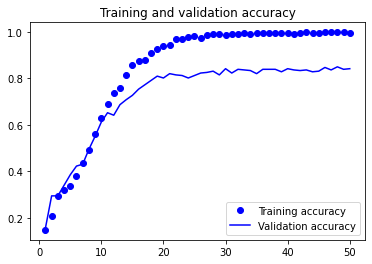

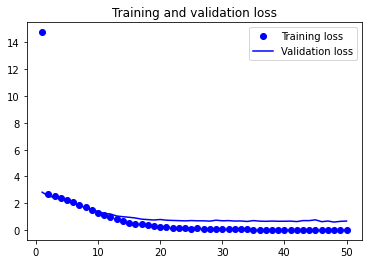

In [46]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label  ="Training accuracy") 
plt.plot(epochs, val_accuracy, "b", label = "Validation accuracy") 
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label = "Training loss") 
plt.plot(epochs, val_loss, "b", label = "Validation loss") 
plt.title("Training and validation loss")
plt.legend()
plt.show()